### Análisis Exploratorio de Datos de HAM10000

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
               age
count  9958.000000
mean     51.863828
std      16.968614
min       0.000000
25%      40.000000
50%      50.000000
75%      65.000000
max      85.000000


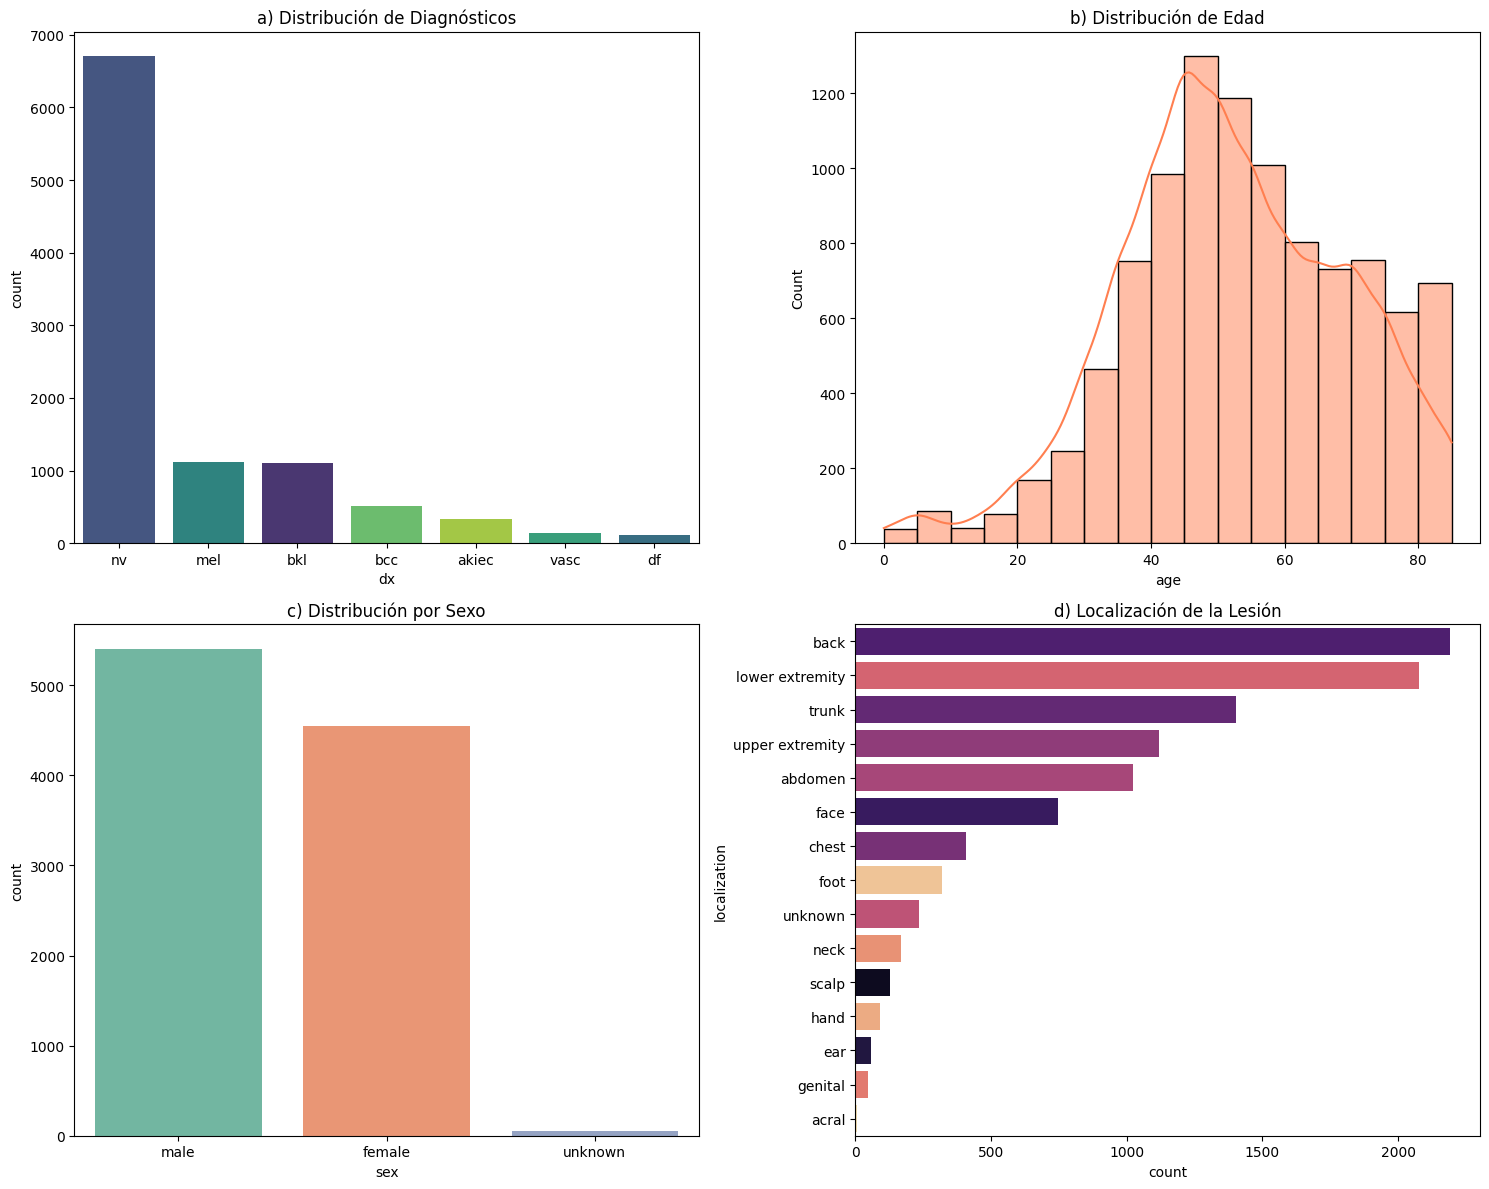

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargamos tu archivo real
df = pd.read_csv('./datasets/ham10000/HAM10000_metadata.csv')

df.info()
print(df.describe())

# Preparamos el lienzo
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Diagnóstico (Ordenado para ver el desbalance)
# Solución: Añadimos hue='dx' y legend=False
sns.countplot(data=df, x='dx', hue='dx', order=df['dx'].value_counts().index, ax=axes[0, 0], palette='viridis', legend=False)
axes[0, 0].set_title('a) Distribución de Diagnósticos')

# Gráfico 2: Edad
# Este se queda igual, ya que histplot usa un color único ('color') y no una paleta ('palette')
sns.histplot(data=df, x='age', bins=17, kde=True, ax=axes[0, 1], color='coral')
axes[0, 1].set_title('b) Distribución de Edad')

# Gráfico 3: Sexo
# Solución: Añadimos hue='sex' y legend=False
sns.countplot(data=df, x='sex', hue='sex', order=df['sex'].value_counts().index, ax=axes[1, 0], palette='Set2', legend=False)
axes[1, 0].set_title('c) Distribución por Sexo')

# Gráfico 4: Localización
# Solución: Como aquí las barras son horizontales (y='localization'), el hue debe ser igual a 'localization'
sns.countplot(data=df, y='localization', hue='localization', order=df['localization'].value_counts().index, ax=axes[1, 1], palette='magma', legend=False)
axes[1, 1].set_title('d) Localización de la Lesión')

plt.tight_layout()
plt.show()

In [ ]:
print("--- 1. RECUENTO DE VALORES ÚNICOS ---")
# nunique() nos dice cuántas opciones distintas hay por cada columna
print(df.nunique())

print("\n--- 2. ¿QUÉ HAY DENTRO DE LAS CATEGORÍAS? ---")
# Para las variables de texto, a veces queremos ver exactamente cuáles son esas opciones
columnas_interes = ['dx', 'dx_type', 'sex']
for col in columnas_interes:
    print(f"\nValores únicos en '{col}':")
    print(df[col].unique())

print("\n--- 3. DUPLICADOS ---")
# Primero, buscamos si hay filas donde ABSOLUTAMENTE TODO sea idéntico
filas_clonadas = df.duplicated().sum()
print(f"Filas 100% duplicadas (errores de registro): {filas_clonadas}")

# Y ahora, el detalle vital del HAM10000:
# ¿Hay alguna foto repetida? ¿Y cuántas pecas tienen múltiples fotos?
fotos_duplicadas = df['image_id'].duplicated().sum()
lesiones_duplicadas = df['lesion_id'].duplicated().sum()

print(f"Imágenes con el mismo ID (fotos repetidas): {fotos_duplicadas}")
print(f"Lesiones con el mismo ID (misma peca, varias fotos): {lesiones_duplicadas}")

--- 1. RECUENTO DE VALORES ÚNICOS ---
lesion_id        7470
image_id        10015
dx                  7
dx_type             4
age                18
sex                 3
localization       15
dtype: int64

--- 2. ¿QUÉ HAY DENTRO DE LAS CATEGORÍAS? ---

Valores únicos en 'dx':
['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']

Valores únicos en 'dx_type':
['histo' 'consensus' 'confocal' 'follow_up']

Valores únicos en 'sex':
['male' 'female' 'unknown']

--- 3. LA CAZA DE LOS DUPLICADOS ---
Filas 100% duplicadas (errores de registro): 0
Imágenes con el mismo ID (fotos repetidas): 0
Lesiones con el mismo ID (misma peca, varias fotos): 2545
